In [15]:
import pandas as pd

#outside of folder because file is too large to upload to github
#use raw string because of unicode error otherwise
data = pd.read_csv(r"C:\Users\gabri\INST414\Crime_Data_from_2020_to_Present.csv", index_col="DR_NO")

In [16]:
data

,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
DR_NO,,,,,,,,,,,,,,,,,,,,,
190326475,03/01/2020 12:00:00 AM,03/01/2020 12:00:00 AM,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,NaN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
200106753,02/09/2020 12:00:00 AM,02/08/2020 12:00:00 AM,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,1822 1402 0344,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
200320258,11/11/2020 12:00:00 AM,11/04/2020 12:00:00 AM,1700,3,Southwest,356,1,480,BIKE - STOLEN,0344 1251,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
200907217,05/10/2023 12:00:00 AM,03/10/2020 12:00:00 AM,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),0325 1501,...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
200412582,09/09/2020 12:00:00 AM,09/09/2020 12:00:00 AM,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,NaN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250304214,02/23/2025 12:00:00 AM,02/21/2025 12:00:00 AM,1530,3,Southwest,358,1,510,VEHICLE - STOLEN,NaN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,3600 MCCLINTOCK AV,NaN,34.0212,-118.2895
250304203,02/20/2025 12:00:00 AM,02/13/2025 12:00:00 AM,2100,3,Southwest,325,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",NaN,...,IC,Invest Cont,522.0,NaN,NaN,NaN,2600 ELLENDALE PL,NaN,34.0307,-118.2923
250504051,01/14/2025 12:00:00 AM,01/14/2025 12:00:00 AM,1250,5,Harbor,509,1,210,ROBBERY,1822 0344 1259,...,IC,Invest Cont,210.0,NaN,NaN,NaN,24300 WESTERN AV,NaN,33.8046,-118.3074


data I want to keep from this:
time occ - will have to manually change to early morning, morning, mid-day, afternoon, evening, night 
area - dummies
crm cd - crime code - need dummies
mocodes - dummies
status - dummies
vict_sex - dumies
vict_descent - dummies
premis cd - dummies
weapon used code - dummies  

In [17]:
data['hour'] = data['TIME OCC'] // 100
data['minute'] = data["TIME OCC"] % 100

data['total_minutes'] = data['hour'] * 60 + data['minute']

def get_time_of_day(minutes):
    if 300 <= minutes < 720:
        return 'morning'
    if 720 <= minutes < 1020:
        return 'afternoon'
    if 1020 <= minutes < 1260:
        return 'evening'
    else:
        return 'night'

data['time_of_day'] = data['total_minutes'].apply(get_time_of_day)

def get_age_range(age):
    if age == 0:
        return 'age_NA'
    if 0 < age < 13:
        return 'child'
    if 13 <= age < 18:
        return 'teenager'
    if 18 <= age < 27:
        return 'young adult'
    if 27 <= age < 65:
        return 'adult'
    else:
        return 'senior'
    
data['vict age range'] = data['Vict Age'].apply(get_age_range)

data['DATE OCC'] = pd.to_datetime(data['DATE OCC'], format='%m/%d/%Y %I:%M:%S %p')
data = data[data['DATE OCC'] >= '2024-01-01']
data

,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,...,Crm Cd 4,LOCATION,Cross Street,LAT,LON,hour,minute,total_minutes,time_of_day,vict age range
DR_NO,,,,,,,,,,,,,,,,,,,,,
242108414,04/25/2024 12:00:00 AM,2024-04-25,1600,21,Topanga,2146,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1606 0344 1402 0302 1822 1227 1420,...,NaN,21400 SHERMAN WY,NaN,34.2010,-118.5977,16,0,960,afternoon,age_NA
240604934,01/21/2024 12:00:00 AM,2024-01-21,1510,6,Hollywood,668,2,624,BATTERY - SIMPLE ASSAULT,1822 0400 0416,...,NaN,1300 N WESTERN AV,NaN,34.0944,-118.3125,15,10,910,afternoon,young adult
241110315,08/29/2024 12:00:00 AM,2024-08-28,1500,11,Northeast,1123,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),NaN,...,NaN,3600 BRUNSWICK AV,NaN,34.1187,-118.2604,15,0,900,afternoon,age_NA
242107187,03/22/2024 12:00:00 AM,2024-03-22,1815,21,Topanga,2145,2,624,BATTERY - SIMPLE ASSAULT,0448 2021 0361 0603,...,NaN,22000 GILMORE ST,NaN,34.1876,-118.6070,18,15,1095,evening,adult
241010884,09/06/2024 12:00:00 AM,2024-09-05,1800,10,West Valley,1027,1,330,BURGLARY FROM VEHICLE,1300 1822 0344,...,NaN,6800 LOUISE AV,NaN,34.1939,-118.5098,18,0,1080,evening,adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250304214,02/23/2025 12:00:00 AM,2025-02-21,1530,3,Southwest,358,1,510,VEHICLE - STOLEN,NaN,...,NaN,3600 MCCLINTOCK AV,NaN,34.0212,-118.2895,15,30,930,afternoon,age_NA
250304203,02/20/2025 12:00:00 AM,2025-02-13,2100,3,Southwest,325,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",NaN,...,NaN,2600 ELLENDALE PL,NaN,34.0307,-118.2923,21,0,1260,night,age_NA
250504051,01/14/2025 12:00:00 AM,2025-01-14,1250,5,Harbor,509,1,210,ROBBERY,1822 0344 1259,...,NaN,24300 WESTERN AV,NaN,33.8046,-118.3074,12,50,770,afternoon,teenager


In [18]:
#problem - took 15 minutes to process without any output, therefore to fix need to limit to just 2024 entries 
column_names = ["AREA", "time_of_day", "Crm Cd", "Mocodes", "vict age range", "Vict Sex", "Vict Descent", "Premis Cd", "Weapon Used Cd", "Status"]

dummies_to_concat = []

for column in column_names:
    dummies = data[f'{column}'].astype(str).str.get_dummies(sep=' ')
    dummies_to_concat.append(dummies)

encoded = pd.concat([data] + dummies_to_concat, axis=1)
encoded

,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,...,515.0,516.0,nan,AA,AO,CC,IC,JA,JO,nan
DR_NO,,,,,,,,,,,,,,,,,,,,,
242108414,04/25/2024 12:00:00 AM,2024-04-25,1600,21,Topanga,2146,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1606 0344 1402 0302 1822 1227 1420,...,0,0,0,0,1,0,0,0,0,0
240604934,01/21/2024 12:00:00 AM,2024-01-21,1510,6,Hollywood,668,2,624,BATTERY - SIMPLE ASSAULT,1822 0400 0416,...,0,0,0,0,0,0,1,0,0,0
241110315,08/29/2024 12:00:00 AM,2024-08-28,1500,11,Northeast,1123,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),NaN,...,0,0,1,0,0,0,1,0,0,0
242107187,03/22/2024 12:00:00 AM,2024-03-22,1815,21,Topanga,2145,2,624,BATTERY - SIMPLE ASSAULT,0448 2021 0361 0603,...,0,0,0,0,1,0,0,0,0,0
241010884,09/06/2024 12:00:00 AM,2024-09-05,1800,10,West Valley,1027,1,330,BURGLARY FROM VEHICLE,1300 1822 0344,...,0,0,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250304214,02/23/2025 12:00:00 AM,2025-02-21,1530,3,Southwest,358,1,510,VEHICLE - STOLEN,NaN,...,0,0,1,0,0,0,1,0,0,0
250304203,02/20/2025 12:00:00 AM,2025-02-13,2100,3,Southwest,325,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",NaN,...,0,0,1,0,0,0,1,0,0,0
250504051,01/14/2025 12:00:00 AM,2025-01-14,1250,5,Harbor,509,1,210,ROBBERY,1822 0344 1259,...,0,0,0,0,0,0,1,0,0,0


In [19]:
encoded = encoded.iloc[:, 32:]

In [20]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50, random_state=42)
encoded_reduced = svd.fit_transform(encoded)

print("Original shape: ", encoded.shape)
print("Reduced shape: ", encoded_reduced.shape)

Original shape:  (127868, 1151)
Reduced shape:  (127868, 50)


In [21]:
#using elbow method to find best k value 
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt 


#needed to process data in batches
inertia_values = []
for k in range(2,31):
    kmeans = MiniBatchKMeans(n_clusters=k, batch_size=100, random_state=42)
    kmeans.fit(encoded_reduced)
    inertia_values.append(kmeans.inertia_)

In [22]:
prev = inertia_values[0]
for inertia in inertia_values[1:]:
    print(prev-inertia)
    prev=inertia

69078.92822720448
40784.0640966394
29797.405931864283
11698.358243283583
10990.95958089258
5079.7583252519835
8903.128726992756
8707.850308474037
4231.168957872433
6414.38751651434
6935.641927859746
7271.071338944952
6608.424235572573
11837.806018197036
4525.728292414569
927.6728084051283
9670.106267728435
164.23509534954792
13328.033278877207
619.237865763891
3529.2508615521365
1986.847987194138
548.1964561766363
4119.18908944889
1941.5355136053986
873.7423509958899
4742.53299725207
6660.7134140357375


<function matplotlib.pyplot.show(close=None, block=None)>

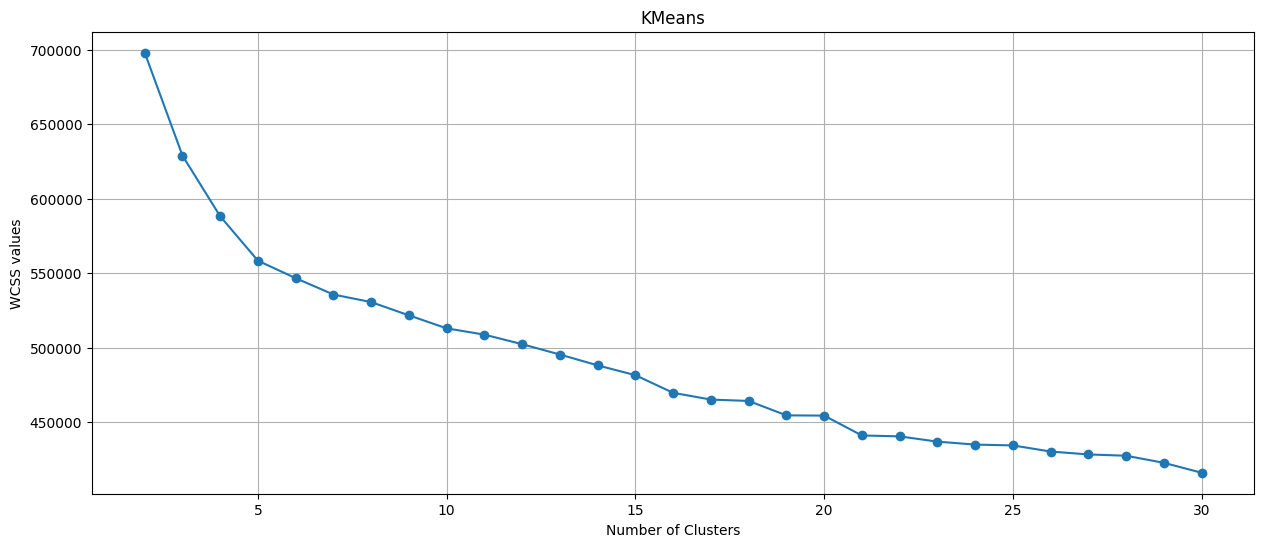

In [23]:
plt.figure(figsize=(15,6))
plt.title("KMeans")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS values")
plt.plot(range(2,31), inertia_values,marker='o')
plt.grid(True)
plt.show

In [24]:
#seems like 7 could be a good number of clusters
from sklearn.cluster import KMeans
encoded_reduced_df = pd.DataFrame(encoded_reduced)
kmeans = KMeans(n_clusters=7, random_state=42)
cluster_labels = kmeans.fit_predict(encoded_reduced_df)
encoded_reduced_df['clusters'] = cluster_labels
grouped = encoded_reduced_df.groupby('clusters')

print(f"Number of crimes per cluster: {encoded_reduced_df['clusters'].value_counts()}")

Number of crimes per cluster: clusters
3    29344
2    28644
4    23496
0    16052
6    11875
5     9359
1     9098
Name: count, dtype: int64


In [25]:
data['clusters'] = cluster_labels
data

C:\Users\gabri\AppData\Local\Temp\ipykernel_19824\489773916.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['clusters'] = cluster_labels


,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,...,LOCATION,Cross Street,LAT,LON,hour,minute,total_minutes,time_of_day,vict age range,clusters
DR_NO,,,,,,,,,,,,,,,,,,,,,
242108414,04/25/2024 12:00:00 AM,2024-04-25,1600,21,Topanga,2146,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1606 0344 1402 0302 1822 1227 1420,...,21400 SHERMAN WY,NaN,34.2010,-118.5977,16,0,960,afternoon,age_NA,2
240604934,01/21/2024 12:00:00 AM,2024-01-21,1510,6,Hollywood,668,2,624,BATTERY - SIMPLE ASSAULT,1822 0400 0416,...,1300 N WESTERN AV,NaN,34.0944,-118.3125,15,10,910,afternoon,young adult,0
241110315,08/29/2024 12:00:00 AM,2024-08-28,1500,11,Northeast,1123,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),NaN,...,3600 BRUNSWICK AV,NaN,34.1187,-118.2604,15,0,900,afternoon,age_NA,3
242107187,03/22/2024 12:00:00 AM,2024-03-22,1815,21,Topanga,2145,2,624,BATTERY - SIMPLE ASSAULT,0448 2021 0361 0603,...,22000 GILMORE ST,NaN,34.1876,-118.6070,18,15,1095,evening,adult,0
241010884,09/06/2024 12:00:00 AM,2024-09-05,1800,10,West Valley,1027,1,330,BURGLARY FROM VEHICLE,1300 1822 0344,...,6800 LOUISE AV,NaN,34.1939,-118.5098,18,0,1080,evening,adult,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250304214,02/23/2025 12:00:00 AM,2025-02-21,1530,3,Southwest,358,1,510,VEHICLE - STOLEN,NaN,...,3600 MCCLINTOCK AV,NaN,34.0212,-118.2895,15,30,930,afternoon,age_NA,3
250304203,02/20/2025 12:00:00 AM,2025-02-13,2100,3,Southwest,325,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",NaN,...,2600 ELLENDALE PL,NaN,34.0307,-118.2923,21,0,1260,night,age_NA,3
250504051,01/14/2025 12:00:00 AM,2025-01-14,1250,5,Harbor,509,1,210,ROBBERY,1822 0344 1259,...,24300 WESTERN AV,NaN,33.8046,-118.3074,12,50,770,afternoon,teenager,4


In [26]:
#figuring out cluster assignments
for cluster_id, group in data.groupby('clusters'):
    print(f"Cluster {cluster_id}")
    cluster_summary = group[['Crm Cd Desc', 'AREA NAME', 'Mocodes', 'vict age range', 'Vict Sex', 'Vict Descent', 'Weapon Desc', 'Premis Cd', 'time_of_day']]
    print(cluster_summary)

Cluster 0
                                              Crm Cd Desc   AREA NAME  \
DR_NO                                                                   
240604934                        BATTERY - SIMPLE ASSAULT   Hollywood   
242107187                        BATTERY - SIMPLE ASSAULT     Topanga   
240607797                                   OTHER ASSAULT   Hollywood   
240904953                        BATTERY - SIMPLE ASSAULT    Van Nuys   
240506784                               CRIMINAL HOMICIDE      Harbor   
...                                                   ...         ...   
251904183    ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER     Mission   
251904146  ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT     Mission   
251704149                        BATTERY - SIMPLE ASSAULT  Devonshire   
251704066                        BATTERY - SIMPLE ASSAULT  Devonshire   
251904184    ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER     Mission   

                                      Mo